<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/29_Hypothesis_Testing_in_Python/03_Proportion_Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt
from scipy.stats import norm

In [2]:

import pandas as pd

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/29_Hypothesis_Testing_in_Python/dataset/late_shipments.feather"
# Read the CSV file
# The original code tried to read a feather file as a CSV, and had a UnicodeDecodeError.
# The file extension is feather, so it should be read using pd.read_feather.
# Also, the variable name was confusing, it should be spotify_population.
late_shipments = pd.read_feather(url)
display(late_shipments.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/churn.csv"
# Read the CSV file
churn = pd.read_csv(url)
display(churn.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/26_Introduction_to_Regression_with_statsmodels_in_Python/dataset/ad_conversion.csv"
# Read the CSV file
ad_conversion = pd.read_csv(url)
display(ad_conversion.head())

,id,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,late_delivery,late,product_group,sub_classification,...,line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,freight_cost_groups,line_item_insurance_usd
0,36203.0,Nigeria,PMO - US,Direct Drop,EXW,Air,1.0,Yes,HRDT,HIV test,...,2996.0,266644.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,1426.0,33279.83,expensive,373.83
1,30998.0,Botswana,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,25.0,800.00,32.00,1.60,"Trinity Biotech, Plc",Yes,10.0,559.89,reasonable,1.72
2,69871.0,Vietnam,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,22925.0,110040.00,4.80,0.08,Hetero Unit III Hyderabad IN,Yes,3723.0,19056.13,expensive,181.57
3,17648.0,South Africa,PMO - US,Direct Drop,DDP,Ocean,0.0,No,ARV,Adult,...,152535.0,361507.95,2.37,0.04,"Aurobindo Unit III, India",Yes,7698.0,11372.23,expensive,779.41
4,5647.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test - Ancillary,...,850.0,8.50,0.01,0.00,Inverness Japan,Yes,56.0,360.00,reasonable,0.01


,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089221,-0.721322
1,0,1.182983,3.634435
2,0,-0.846156,-0.427582
3,0,0.086942,-0.535672
4,0,-1.166642,-0.672640


,spent_usd,n_impressions,n_clicks
0,1.43,7350,1
1,1.82,17861,2
2,1.25,4259,1
3,1.29,4133,1
4,4.77,15615,3


**t for proportions?**  
Some of the hypothesis tests in this course have used a
 test statistic and some have used a
 test statistic. To get the correct p-value, you need to use the right type of test statistic.

Do tests of proportion(s) use a
z or a t
 test statistic and why?

 -> z: The test statistic for proportion(s) has only one estimate of a parameter instead of two.

  *The t-test is needed for tests of mean(s) since you are estimating two unknown quantities, which leads to more variability.*

**Test for single proportions**  
In Chapter 1, you calculated a p-value for a test hypothesizing that the proportion of late shipments was greater than 6%. In that chapter, you used a bootstrap distribution to estimate the standard error of the statistic. An alternative is to use an equation for the standard error based on the sample proportion, hypothesized proportion, and sample size.

 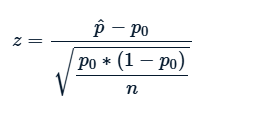


You'll revisit the p-value using this simpler calculation.

late_shipments is available. pandas and numpy are available under their usual aliases, and norm is loaded from scipy.stats.

In [6]:
# Hypothesize that the proportion of late shipments is 6%
p_0 = 0.06

# Calculate the sample proportion of late shipments
p_hat = (late_shipments['late'] == "Yes").mean()

# Calculate the sample size
n = len(late_shipments)

# Calculate the numerator and denominator of the test statistic
numerator = p_hat - p_0
denominator = np.sqrt(p_0 * (1 - p_0) / n)

# Calculate the test statistic
z_score = numerator / denominator

# Calculate the p-value from the z-score
p_value = 1 - norm.cdf(z_score)

# Print the p-value
print(p_value)

# While bootstrapping can be used to estimate the standard error of any statistic,
# it is computationally intensive. For proportions, using a simple equation of the hypothesized proportion and sample size is easier to compute.

0.44703503936503364


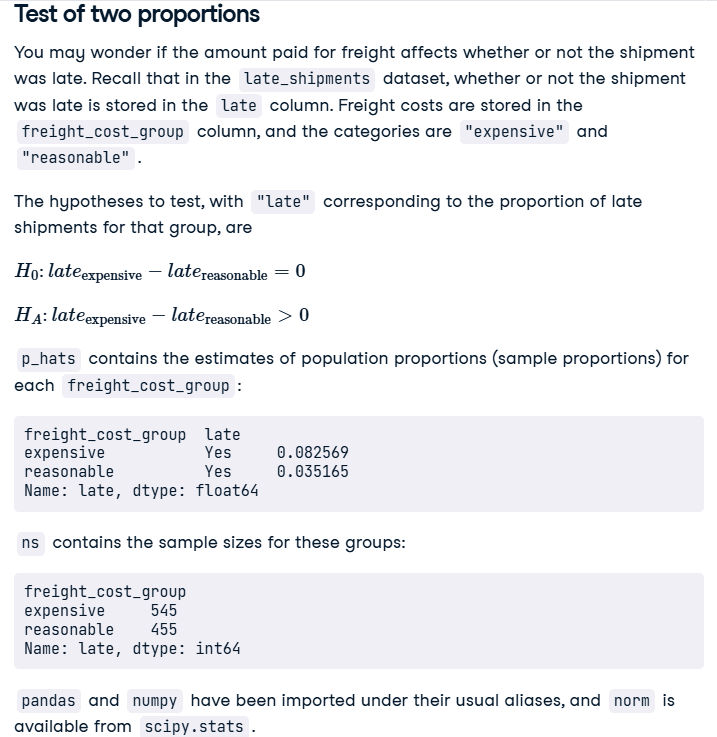

In [10]:
# Calculate the sample proportion of late shipments for each freight_cost_groups
p_hats = late_shipments.groupby('freight_cost_groups')['late'].apply(lambda x: (x == "Yes").mean())

# Calculate the sample size for each freight_cost_groups
ns = late_shipments.groupby('freight_cost_groups')['late'].count()

In [9]:
# Calculate the pooled estimate of the population proportion
p_hat = (p_hats["reasonable"] * ns["reasonable"] + p_hats["expensive"] * ns["expensive"]) / (ns["reasonable"] + ns["expensive"])

# Calculate p_hat one minus p_hat
p_hat_times_not_p_hat = p_hat * (1 - p_hat)

# Divide this by each of the sample sizes and then sum
p_hat_times_not_p_hat_over_ns = p_hat_times_not_p_hat / ns["expensive"] + p_hat_times_not_p_hat / ns["reasonable"]

# Calculate the standard error
std_error = np.sqrt(p_hat_times_not_p_hat_over_ns)

# Calculate the z-score
z_score = (p_hats["expensive"] - p_hats["reasonable"]) / std_error

# Calculate the p-value from the z-score
p_value = 1 - norm.cdf(z_score)

# Print p_value
print(p_value)

# You can calculate a p-value for a two sample proportion test using (a rather
# exhausting amount of) arithmetic. This tiny p-value leads us to suspect there is
# a larger proportion of late shipments for expensive freight compared to reasonable freight.

0.0017353400023595311


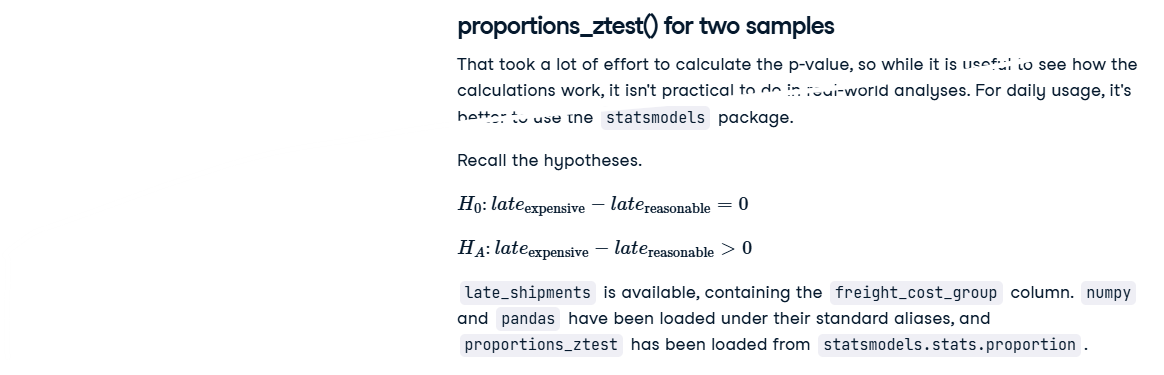

In [12]:
# Count the late column values for each freight_cost_groups
late_by_freight_cost_group = late_shipments.groupby("freight_cost_groups")['late'].value_counts()

# Create an array of the "Yes" counts for each freight_cost_groups
success_counts = np.array([late_by_freight_cost_group["expensive"]["Yes"], late_by_freight_cost_group["reasonable"]["Yes"]])

# Create an array of the total number of rows in each freight_cost_groups
n = np.array([late_by_freight_cost_group["expensive"].sum(), late_by_freight_cost_group["reasonable"].sum()])

from statsmodels.stats.proportion import proportions_ztest

# Run a z-test on the two proportions
stat, p_value = proportions_ztest(count=success_counts, nobs=n, alternative="larger")

# Print the results
print(stat, p_value)

# Delightful déjà vu! statsmodels's .proportions_ztest() method gives the same results with less effort.

2.922648567784529 0.001735340002359578


**Like the t-distribution, the chi-square distribution has degrees of freedom and non-centrality parameters. When these numbers are large, the chi-square distribution can be approximated by a normal distribution.  
The chi-square test statistic is a square number, so it is always non-negative, so only the right tail tends to be of interest.**

**Performing a chi-square test**  
The chi-square independence test compares proportions of successes of one categorical variable across the categories of another categorical variable.

Trade deals often use a form of business shorthand in order to specify the exact details of their contract. These are International Chamber of Commerce (ICC) international commercial terms, or incoterms for short.

The late_shipments dataset includes a vendor_inco_term that describes the incoterms that applied to a given shipment. The choices are:

    EXW: "Ex works". The buyer pays for transportation of the goods.
    CIP: "Carriage and insurance paid to". The seller pays for freight and insurance until the goods board a ship.
    DDP: "Delivered duty paid". The seller pays for transportation of the goods until they reach a destination port.
    FCA: "Free carrier". The seller pays for transportation of the goods.
Perhaps the incoterms affect whether or not the freight costs are expensive. Test these hypotheses with a significance level of 0.01.

`H0: vendor_inco_term and freight_cost_group are independent.`

`Ha: vendor_inco_term and freight_cost_group are associated.`

late_shipments is available, and the following have been loaded: matplotlib.pyplot as plt, pandas as pd, and pingouin.

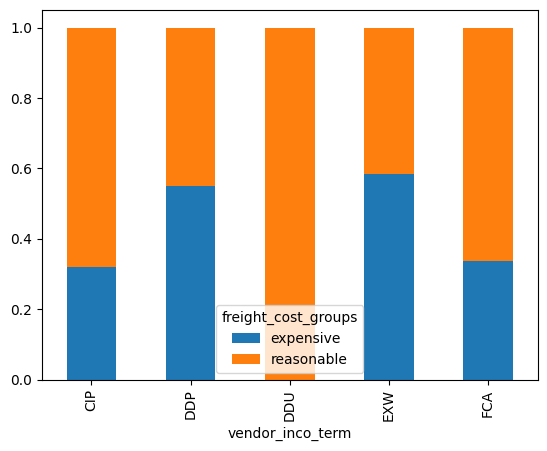

ModuleNotFoundError: No module named 'pingouin'

In [18]:
# Proportion of freight_cost_group grouped by vendor_inco_term
props = late_shipments.groupby('vendor_inco_term')['freight_cost_groups'].value_counts(normalize=True)

# Convert props to wide format
wide_props = props.unstack()

# Proportional stacked bar plot of freight_cost_group vs. vendor_inco_term
wide_props.plot(kind="bar", stacked=True)
plt.show()

import pingouin
# Determine if freight_cost_group and vendor_inco_term are independent
expected, observed, stats = pingouin.chi2_independence(data=late_shipments, x="vendor_inco_term", y="freight_cost_groups")

# Print results
print(stats[stats['test'] == 'pearson'])

# The test to compare proportions of successes in a categorical variable across
# groups of another categorical variable is called a chi-square test of independence.

In [19]:
%pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 4.6 MB/s eta 0:00:00


**Visualizing goodness of fit**  
The chi-square goodness of fit test compares proportions of each level of a categorical variable to hypothesized values. Before running such a test, it can be helpful to visually compare the distribution in the sample to the hypothesized distribution.

Recall the vendor incoterms in the late_shipments dataset. You hypothesize that the four values occur with these frequencies in the population of shipments.

    CIP: 0.05
    DDP: 0.1
    EXW: 0.75
    FCA: 0.1
These frequencies are stored in the hypothesized DataFrame.

The incoterm_counts DataFrame stores the .value_counts() of the vendor_inco_term column.

late_shipments is available; pandas and matplotlib.pyplot are loaded with their standard aliases.

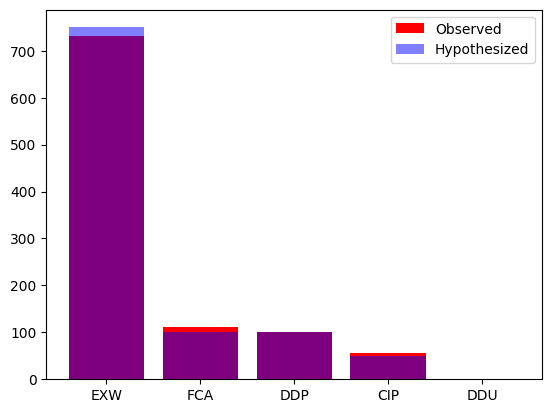

In [27]:
# Find the number of rows in late_shipments
n_total = len(late_shipments)

# Create n column that is prop column * n_total
hypothesized["n"] = hypothesized["prop"] * n_total

# Plot a red bar graph of n vs. vendor_inco_term for incoterm_counts
plt.bar(incoterm_counts['vendor_inco_term'], incoterm_counts['n'], color="red", label="Observed")

# Add a blue bar plot for the hypothesized counts
plt.bar(hypothesized['vendor_inco_term'], hypothesized['n'], alpha=0.5, color="blue", label="Hypothesized")
plt.legend()
plt.show()

#  Two of the bars in the sample are very close to the hypothesized values:
#  one is a little high and one is a little low. Head on over to the next exercise to test
#  if these differences are statistically significant.

In [25]:
# Create a DataFrame with the hypothesized frequencies
hypothesized = pd.DataFrame({'vendor_inco_term': ['CIP', 'DDP', 'EXW', 'FCA'],
                             'prop': [0.05, 0.1, 0.75, 0.1]})

In [26]:
# Get the value counts for vendor_inco_term
incoterm_counts = late_shipments['vendor_inco_term'].value_counts().reset_index()
incoterm_counts.columns = ['vendor_inco_term', 'n']

**Performing a goodness of fit test**  
The bar plot of vendor_inco_term suggests that the distribution across the four categories was quite close to the hypothesized distribution. You'll need to perform a chi-square goodness of fit test to see whether the differences are statistically significant.

Recall the hypotheses for this type of test:

H0: The sample matches with the hypothesized distribution.

Ha: The sample does not match with the hypothesized distribution.

To decide which hypothesis to choose, we'll set a significance level of 0.1.

late_shipments, incoterm_counts, and hypothesized from the last exercise are available. chisquare from scipy.stats has been loaded.

In [33]:
from scipy.stats import chisquare

# Filter incoterm_counts to include only categories in hypothesized and reorder
incoterm_counts_filtered = incoterm_counts[incoterm_counts['vendor_inco_term'].isin(hypothesized['vendor_inco_term'])]
incoterm_counts_filtered = incoterm_counts_filtered.set_index('vendor_inco_term').loc[hypothesized['vendor_inco_term']].reset_index()

# Rescale the hypothesized counts to match the sum of observed counts
hypothesized_rescaled = hypothesized.copy()
hypothesized_rescaled['n'] = hypothesized['n'] * (incoterm_counts_filtered['n'].sum() / hypothesized['n'].sum())


# Perform a goodness of fit test on the incoterm counts n
gof_test = chisquare(f_obs=incoterm_counts_filtered['n'],
                     f_exp=hypothesized_rescaled['n'])


# Print gof_test results
print(gof_test)

Power_divergenceResult(statistic=np.float64(2.3633633633633613), pvalue=np.float64(0.5004909543758689))
